# Results

## 1. Testing Best Models

In [1]:
from google.colab import drive
import torch
import torch.optim as optim
from torchvision.utils import save_image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch.optim as optim
import math
import os
from torch.nn import functional as F
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

In [2]:
!pip -q install gdown Ninja
!rm -rf /content/stylegan2-pytorch
!git clone -q https://github.com/rosinality/stylegan2-pytorch.git /content/stylegan2-pytorch
%cd /content/stylegan2-pytorch

import gdown

def dl(fid, out):
    gdown.download(f"https://drive.google.com/uc?id={fid}", out, quiet=False)

FFHQ_ID = "1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT"
dl(FFHQ_ID, "stylegan2-ffhq-config-f.pt")

CKPT_IDS = [
    "13chLH0SuFqiflTDQQZ9kwGwpCJAYLerD",
    "1eD-Ql1IgnU6lYGcZKVZWQr9QXFiAf0EE",
    "1jP8_TjgwtxWyv8rwegw1CrOus-U_HPLE",
    "1XYPcPlZ8Wmm-jTvvGTOncV6-fR4s-whU",
]

CKPT_FILES = ["anime.pt", "statue.pt", "werewolf.pt", "white_walker.pt"]
for fid, out in zip(CKPT_IDS, CKPT_FILES):
    dl(fid, out)

print("Downloaded:", CKPT_FILES)


/content/stylegan2-pytorch


Downloading...
From (original): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT
From (redirected): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT&confirm=t&uuid=eb2d999b-3d9f-41f0-9474-38cd0d45d5c1
To: /content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt
100%|██████████| 381M/381M [00:02<00:00, 145MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=13chLH0SuFqiflTDQQZ9kwGwpCJAYLerD
From (redirected): https://drive.google.com/uc?id=13chLH0SuFqiflTDQQZ9kwGwpCJAYLerD&confirm=t&uuid=d906e1f4-0585-43ba-bee3-dd9ef20ca02f
To: /content/stylegan2-pytorch/anime.pt
100%|██████████| 346M/346M [00:01<00:00, 312MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1eD-Ql1IgnU6lYGcZKVZWQr9QXFiAf0EE
From (redirected): https://drive.google.com/uc?id=1eD-Ql1IgnU6lYGcZKVZWQr9QXFiAf0EE&confirm=t&uuid=40068038-8679-4600-8b25-7d0f298b4345
To: /content/stylegan2-pytorch/statue.pt
100%|██████████| 346M/346M [00:03<00:00, 112MB/s]
Downloading.

Downloaded: ['anime.pt', 'statue.pt', 'werewolf.pt', 'white_walker.pt']


/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.9.0+cu126. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


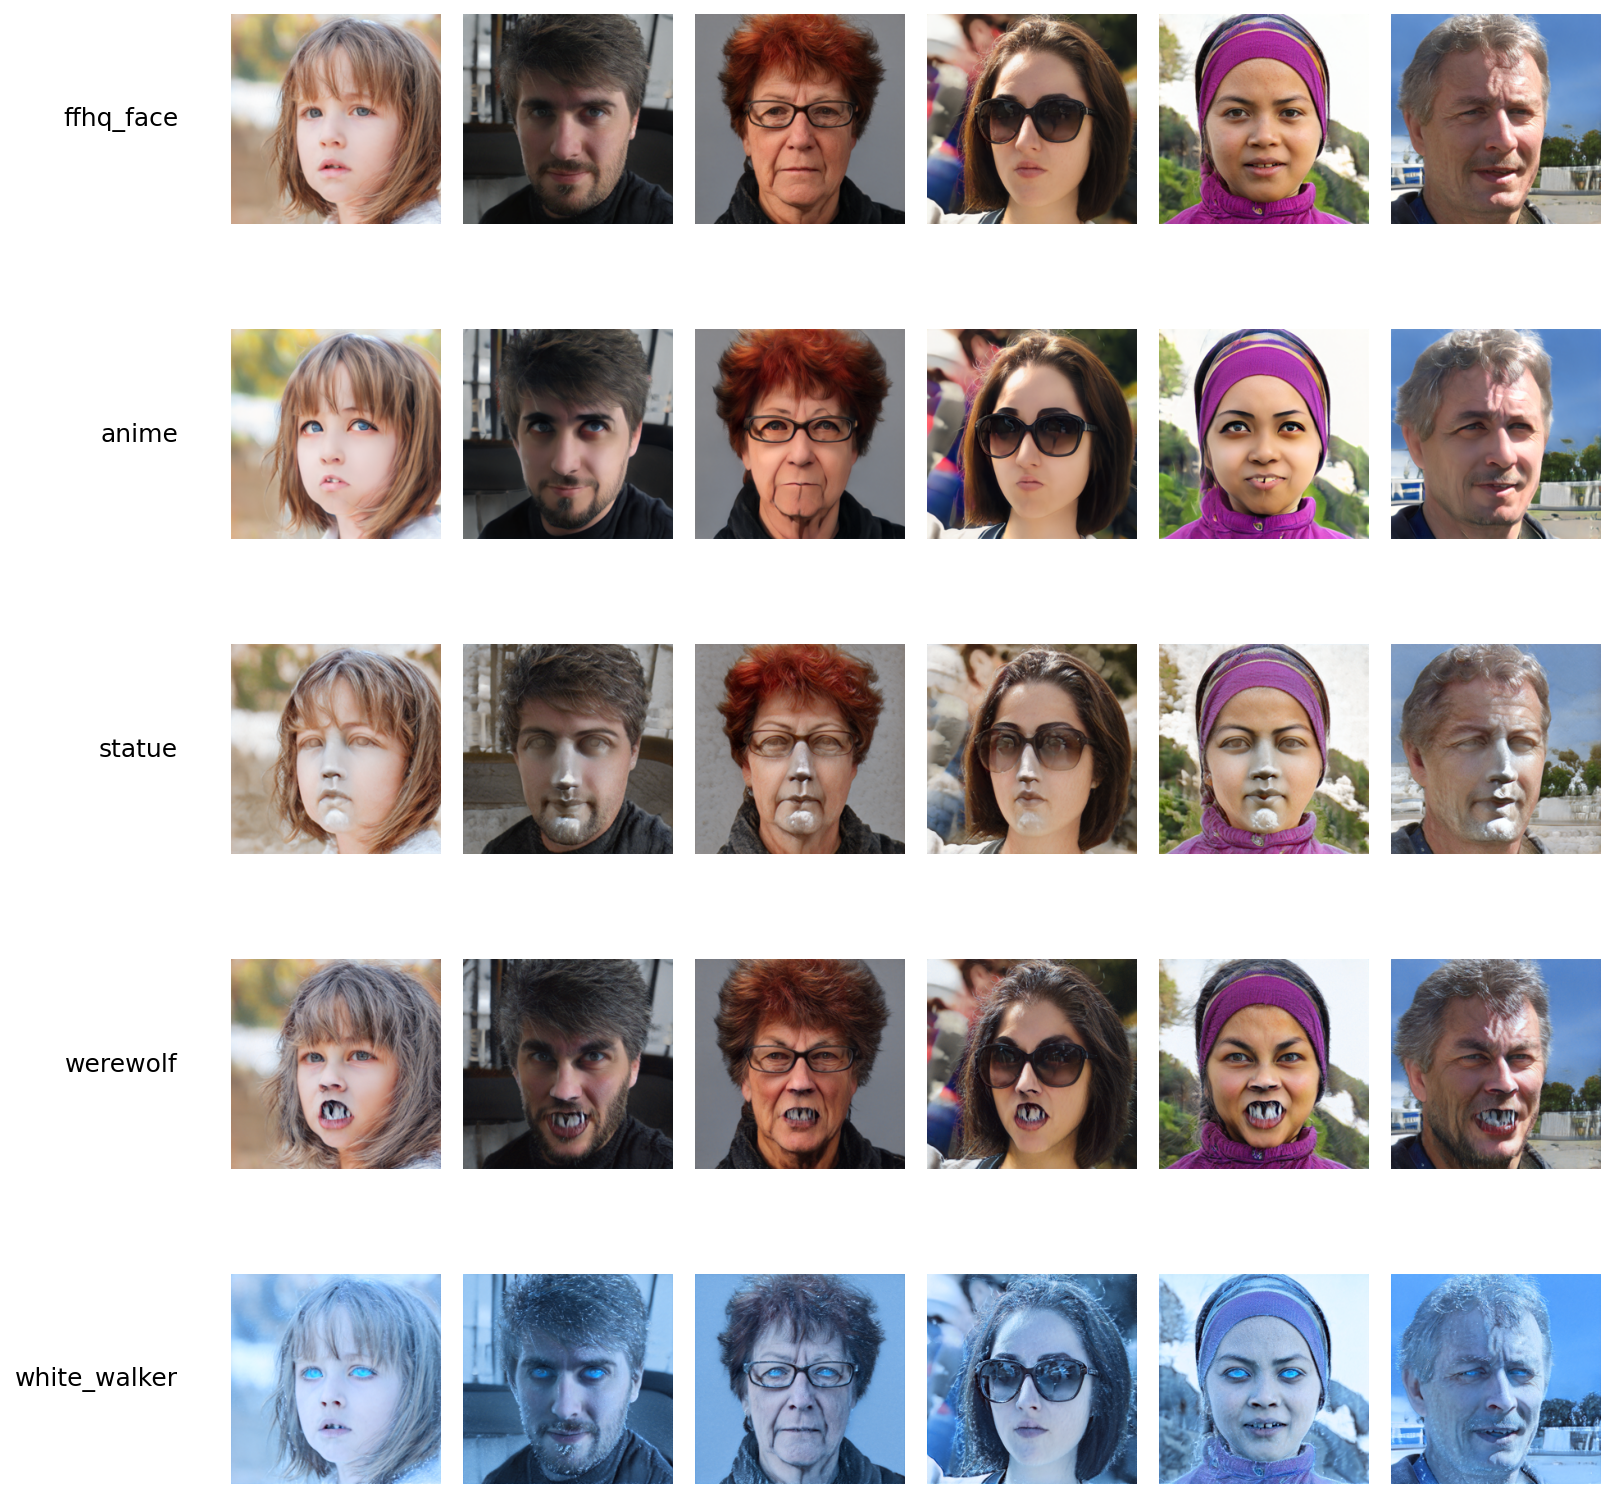

In [3]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from model import Generator

device = "cuda" if torch.cuda.is_available() else "cpu"
latent_dim = 512

def strip_module(sd):
    if isinstance(sd, dict) and any(k.startswith("module.") for k in sd.keys()):
        return {k.replace("module.", "", 1): v for k, v in sd.items()}
    return sd

def load_ffhq(ffhq_path="stylegan2-ffhq-config-f.pt"):
    G = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
    base = torch.load(ffhq_path, map_location=device)
    G.load_state_dict(strip_module(base["g_ema"]), strict=True)
    G.eval()
    return G

def load_G(ckpt_path, ffhq_path="stylegan2-ffhq-config-f.pt"):
    G = load_ffhq(ffhq_path)
    ck = torch.load(ckpt_path, map_location=device)
    sd = ck["generator_t"] if (isinstance(ck, dict) and "generator_t" in ck) else ck
    G.load_state_dict(strip_module(sd), strict=True)
    G.eval()
    return G

@torch.no_grad()
def sample_pils_from_z(G, Z):
    img, _ = G([Z], input_is_latent=False, randomize_noise=False)
    img = ((img.clamp(-1,1) + 1) / 2 * 255).round().to(torch.uint8).cpu()
    return [Image.fromarray(img[i].permute(1,2,0).numpy()) for i in range(img.shape[0])]

def show_rows(rows, titles, thumb=256):
    R, C = len(rows), len(rows[0])
    fig, axes = plt.subplots(R, C, figsize=(1.8*C, 2.2*R), dpi=150)

    for r in range(R):
        for c in range(C):
            ax = axes[r, c]
            ax.axis("off")
            im = rows[r][c].copy()
            im.thumbnail((thumb, thumb))
            ax.imshow(im)
            if c == 0:
                ax.text(-0.25, 0.5, titles[r], transform=ax.transAxes,
                        ha="right", va="center", fontsize=12, clip_on=False)

    plt.subplots_adjust(left=0.18)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

CKPT_FILES = ["anime.pt", "statue.pt", "werewolf.pt", "white_walker.pt"]

names = ["ffhq_face", "anime", "statue", "werewolf", "white_walker"]
Gs = [load_ffhq()] + [load_G(f) for f in CKPT_FILES]

N = 6
seed = 113
g = torch.Generator(device=device).manual_seed(seed)
Z = torch.randn(N, latent_dim, device=device, generator=g)

rows = [sample_pils_from_z(G, Z) for G in Gs]
show_rows(rows, names)


## 2. Real Photo

device: cuda
fatal: destination path '/content/encoder4editing' already exists and is not an empty directory.


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)
Downloading...
From (original): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT
From (redirected): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT&confirm=t&uuid=14fb9413-be1b-4e02-88dd-1516abcc2c65
To: /content/weights/stylegan2-ffhq-config-f.pt
100%|██████████| 381M/381M [00:01<00:00, 232MB/s]
Downloading...
From (original): https://dri

weights ready
Loading e4e over the pSp framework from checkpoint: /content/weights/e4e_ffhq_encode.pt
e4e loaded
generators: ['ffhq_recon', 'anime', 'statue', 'werewolf', 'white_walker']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/70 [00:00<?, ?it/s]

real images: 6
[1/6] e4e encode...
[1/6] render 5 gens...


/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.9.0+cu126. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


[2/6] e4e encode...
[2/6] render 5 gens...
[3/6] e4e encode...
[3/6] render 5 gens...
[4/6] e4e encode...
[4/6] render 5 gens...
[5/6] e4e encode...
[5/6] render 5 gens...
[6/6] e4e encode...
[6/6] render 5 gens...
done: 1.19 sec


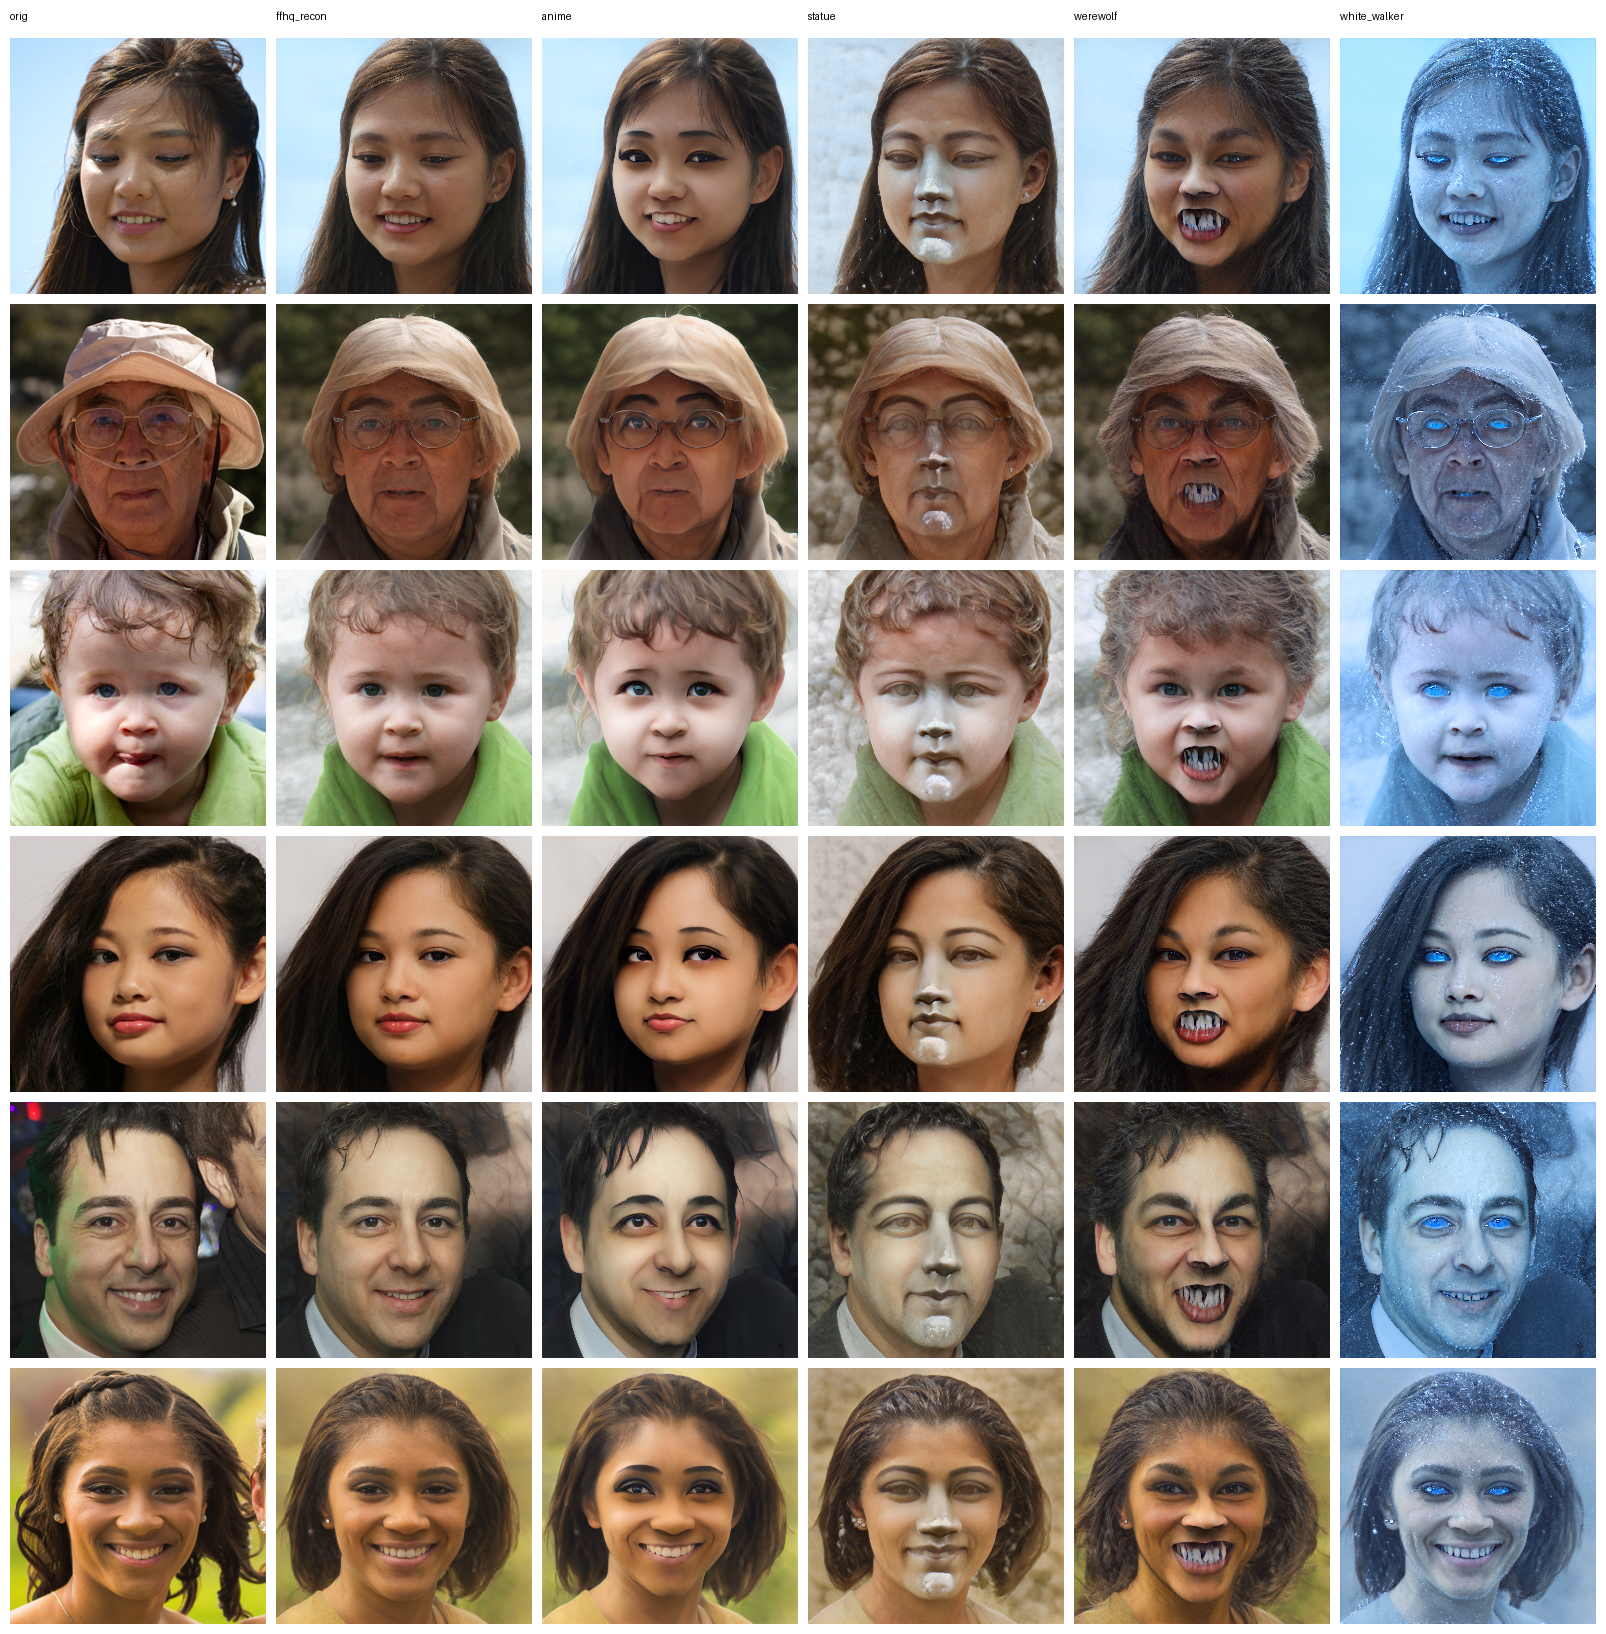

saved: /content/real_ffhq_e4e_grid.png


In [4]:
%matplotlib inline

!pip -q install gdown datasets webdataset ninja

import os, sys, io, time
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print("device:", device)

!git clone -q https://github.com/omertov/encoder4editing.git /content/encoder4editing

import gdown
os.makedirs("/content/weights", exist_ok=True)

def dl(fid, out):
    return gdown.download(id=fid, output=out, quiet=False, fuzzy=True)

FFHQ_ID = "1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT"
FFHQ_W = "/content/weights/stylegan2-ffhq-config-f.pt"
dl(FFHQ_ID, FFHQ_W)

E4E_ID = "1cUv_reLE6k3604or78EranS7XzuVMWeO"
E4E_W = "/content/weights/e4e_ffhq_encode.pt"
dl(E4E_ID, E4E_W)

CKPT_IDS = {
    "anime": "13chLH0SuFqiflTDQQZ9kwGwpCJAYLerD",
    "statue": "1eD-Ql1IgnU6lYGcZKVZWQr9QXFiAf0EE",
    "werewolf": "1jP8_TjgwtxWyv8rwegw1CrOus-U_HPLE",
    "white_walker": "1XYPcPlZ8Wmm-jTvvGTOncV6-fR4s-whU",
}
CKPT_FILES = {}
for name, fid in CKPT_IDS.items():
    out = f"/content/weights/{name}.pt"
    dl(fid, out)
    CKPT_FILES[name] = out

print("weights ready")

from datasets import load_dataset

sys.path.append("/content/encoder4editing")
from argparse import Namespace
from models.psp import pSp

ckpt = torch.load(E4E_W, map_location="cpu")
opts = ckpt["opts"]
opts["checkpoint_path"] = E4E_W
opts = Namespace(**opts)

e4e_net = pSp(opts).to(device).eval()
print("e4e loaded")

sys.path.append("/content/stylegan2-pytorch")
from model import Generator

latent_dim = 512

def strip_module(sd):
    if isinstance(sd, dict) and any(k.startswith("module.") for k in sd.keys()):
        return {k.replace("module.", "", 1): v for k, v in sd.items()}
    return sd

def pick_sd(obj):
    if isinstance(obj, dict):
        for k in ["generator_t", "g_ema", "generator", "g", "state_dict"]:
            if k in obj:
                return obj[k]
    return obj

def load_ffhq(ffhq_path=FFHQ_W):
    G = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
    base = torch.load(ffhq_path, map_location=device)
    G.load_state_dict(strip_module(base["g_ema"]), strict=True)
    G.eval()
    return G

def load_domain(domain_pt, ffhq_path=FFHQ_W):
    G = load_ffhq(ffhq_path)
    ck = torch.load(domain_pt, map_location=device)
    sd = strip_module(pick_sd(ck))
    G.load_state_dict(sd, strict=True)
    G.eval()
    return G

Gs = load_ffhq()
G_list = [("ffhq_recon", Gs)]
for name in ["anime","statue","werewolf","white_walker"]:
    G_list.append((name, load_domain(CKPT_FILES[name])))

print("generators:", [n for n,_ in G_list])

ds = load_dataset("gaunernst/ffhq-1024-wds", split="train", streaming=True)
it = iter(ds)

def item_to_pil(item):
    b = item["webp"]
    if isinstance(b, dict) and "bytes" in b:
        b = b["bytes"]
    if isinstance(b, (bytes, bytearray)):
        return Image.open(io.BytesIO(b)).convert("RGB")
    if isinstance(b, Image.Image):
        return b.convert("RGB")
    return Image.open(b).convert("RGB")

N = 6
SKIP = 300
for _ in range(SKIP):
    next(it)
real_pils = [item_to_pil(next(it)) for _ in range(N)]
print("real images:", len(real_pils))

e4e_tf = T.Compose([
    T.Resize((256,256)),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

@torch.no_grad()
def e4e_encode_wplus(pil_img):
    x = e4e_tf(pil_img).unsqueeze(0).to(device)
    _, wplus = e4e_net(x, return_latents=True, randomize_noise=False)
    return wplus

@torch.no_grad()
def render_256(G, wplus):
    try:
        Gh = G.half()
        wh = wplus.half()
        with torch.autocast("cuda", dtype=torch.float16):
            img, _ = Gh([wh], input_is_latent=True, randomize_noise=False)
        img = img.float()
    except Exception:
        img, _ = G([wplus], input_is_latent=True, randomize_noise=False)

    img = F.interpolate(img, size=(256,256), mode="bilinear", align_corners=False)
    img = ((img.clamp(-1,1) + 1) / 2 * 255).round().to(torch.uint8)[0].cpu()
    return Image.fromarray(img.permute(1,2,0).numpy())

col_titles = ["orig"] + [n for n,_ in G_list]
rows = []
t0 = time.time()
for i, pil in enumerate(real_pils, 1):
    print(f"[{i}/{N}] e4e encode...")
    wplus = e4e_encode_wplus(pil)
    print(f"[{i}/{N}] render {len(G_list)} gens...")
    outs = [render_256(G, wplus) for _,G in G_list]
    rows.append([pil.resize((256,256))] + outs)

print("done:", round(time.time()-t0, 2), "sec")

def make_grid(rows, titles, pad=10, title_h=28, cell=256):
    R = len(rows); C = len(rows[0])
    W = pad + C*(cell+pad)
    H = pad + title_h + R*(cell+pad)
    grid = Image.new("RGB", (W, H), (255,255,255))
    draw = ImageDraw.Draw(grid)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)
    except:
        font = ImageFont.load_default()

    for c,t in enumerate(titles):
        x = pad + c*(cell+pad)
        draw.text((x, pad), str(t), fill=(0,0,0), font=font)

    for r in range(R):
        for c in range(C):
            x = pad + c*(cell+pad)
            y = pad + title_h + r*(cell+pad)
            grid.paste(rows[r][c].resize((cell,cell)), (x,y))
    return grid

grid = make_grid(rows, col_titles)
display(grid)
grid.save("/content/real_ffhq_e4e_grid.png")
print("saved:", "/content/real_ffhq_e4e_grid.png")
